In [1]:
import pandas as pd
dataset = pd.read_csv("41100080.csv")

In [2]:
drop_cols = ["UOM_ID", "SCALAR_FACTOR", "SCALAR_ID", "VECTOR", "SYMBOL", "TERMINATED", "DECIMALS"]
dataset.drop(labels=drop_cols, axis="columns", inplace=True)

In [3]:
dataset = dataset[~(dataset.STATUS == "F")]
dataset.head()

,REF_DATE,GEO,DGUID,Indigenous identity,Age group,Gender,Overall health,Housing - Needs repairs,Persons per room (crowding),Statistics,UOM,COORDINATE,VALUE,STATUS
0,2022,Canada,2021A000011124,"Total, Indigenous identity","Total, 15 years and over","Total, gender","Total, self-perceived general health","Total, housing - Needs repairs","Total, Persons per room (crowding)",Number of persons,Persons,1.1.1.1.1.1.1.1,1077810.0,NaN
1,2022,Canada,2021A000011124,"Total, Indigenous identity","Total, 15 years and over","Total, gender","Total, self-perceived general health","Total, housing - Needs repairs","Total, Persons per room (crowding)",Percent,Percent,1.1.1.1.1.1.1.2,100.0,NaN
2,2022,Canada,2021A000011124,"Total, Indigenous identity","Total, 15 years and over","Total, gender","Total, self-perceived general health","Total, housing - Needs repairs","Total, Persons per room (crowding)",Low 95% confidence interval,Percent,1.1.1.1.1.1.1.3,100.0,NaN
3,2022,Canada,2021A000011124,"Total, Indigenous identity","Total, 15 years and over","Total, gender","Total, self-perceived general health","Total, housing - Needs repairs","Total, Persons per room (crowding)",High 95% confidence interval,Percent,1.1.1.1.1.1.1.4,100.0,NaN
4,2022,Canada,2021A000011124,"Total, Indigenous identity","Total, 15 years and over","Total, gender","Total, self-perceived general health","Total, housing - Needs repairs",One person or fewer per room,Number of persons,Persons,1.1.1.1.1.1.2.1,999250.0,NaN


Gender,Men+,"Total, gender",Women+
Indigenous identity,,,
First Nations (North American Indian),17228.700624,25436.230110,18011.895816
"First Nations (North American Indian), Registered or Treaty Indian",14324.056162,20242.062600,15323.823884
"First Nations (North American Indian), not a Registered or Treaty Indian",12248.429752,15215.048780,11339.705263
Inuk (Inuit),1717.825371,2465.498252,1975.410072
Métis,19493.959505,27269.959211,18979.837893
"Total, Indigenous identity",21333.195084,32205.236314,22103.055176


<Axes: xlabel='VALUE', ylabel='Indigenous identity'>

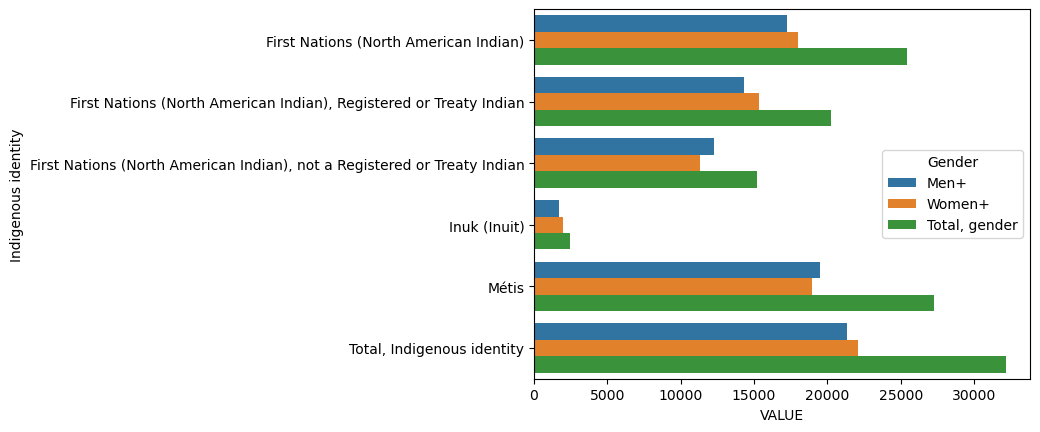

In [145]:
import seaborn as sb

no_of_persons = dataset[dataset.Statistics == "Number of persons"]
id_vs_gender = no_of_persons.pivot_table(index=["Indigenous identity"], columns=["Gender"], values="VALUE")
id_vs_gender = id_vs_gender.drop(index="Indigenous responses not included elsewhere")
display(id_vs_gender)

# id_vs_gender = no_of_persons.pivot_table(index=["Indigenous identity", "Gender"], values="VALUE")

# indigenous_identity = no_of_persons["Indigenous identity"].unique()
# gender_order = ["Men+", "Women+", "Total, gender"]
# new_gender_index = pd.MultiIndex.from_product([indigenous_identity, gender_order], names=["Indigenous identity", "Gender"])
# id_vs_gender = id_vs_gender.reindex(new_gender_index)

id_vs_gender_reset = id_vs_gender.reset_index()
id_vs_gender_long = id_vs_gender_reset.melt(
    id_vars="Indigenous identity",
    value_vars=["Men+", "Women+", "Total, gender"],
    var_name="Gender",
    value_name="VALUE"
)

df_json = id_vs_gender_reset.rename(columns={
    "Indigenous identity": "identity",
    "Men+": "men",
    "Women+": "women",
    "Total, gender": "total"
})

# display(df_json.to_dict(orient="records"))

sb.barplot(data=id_vs_gender_long, y="Indigenous identity", x="VALUE", hue="Gender")

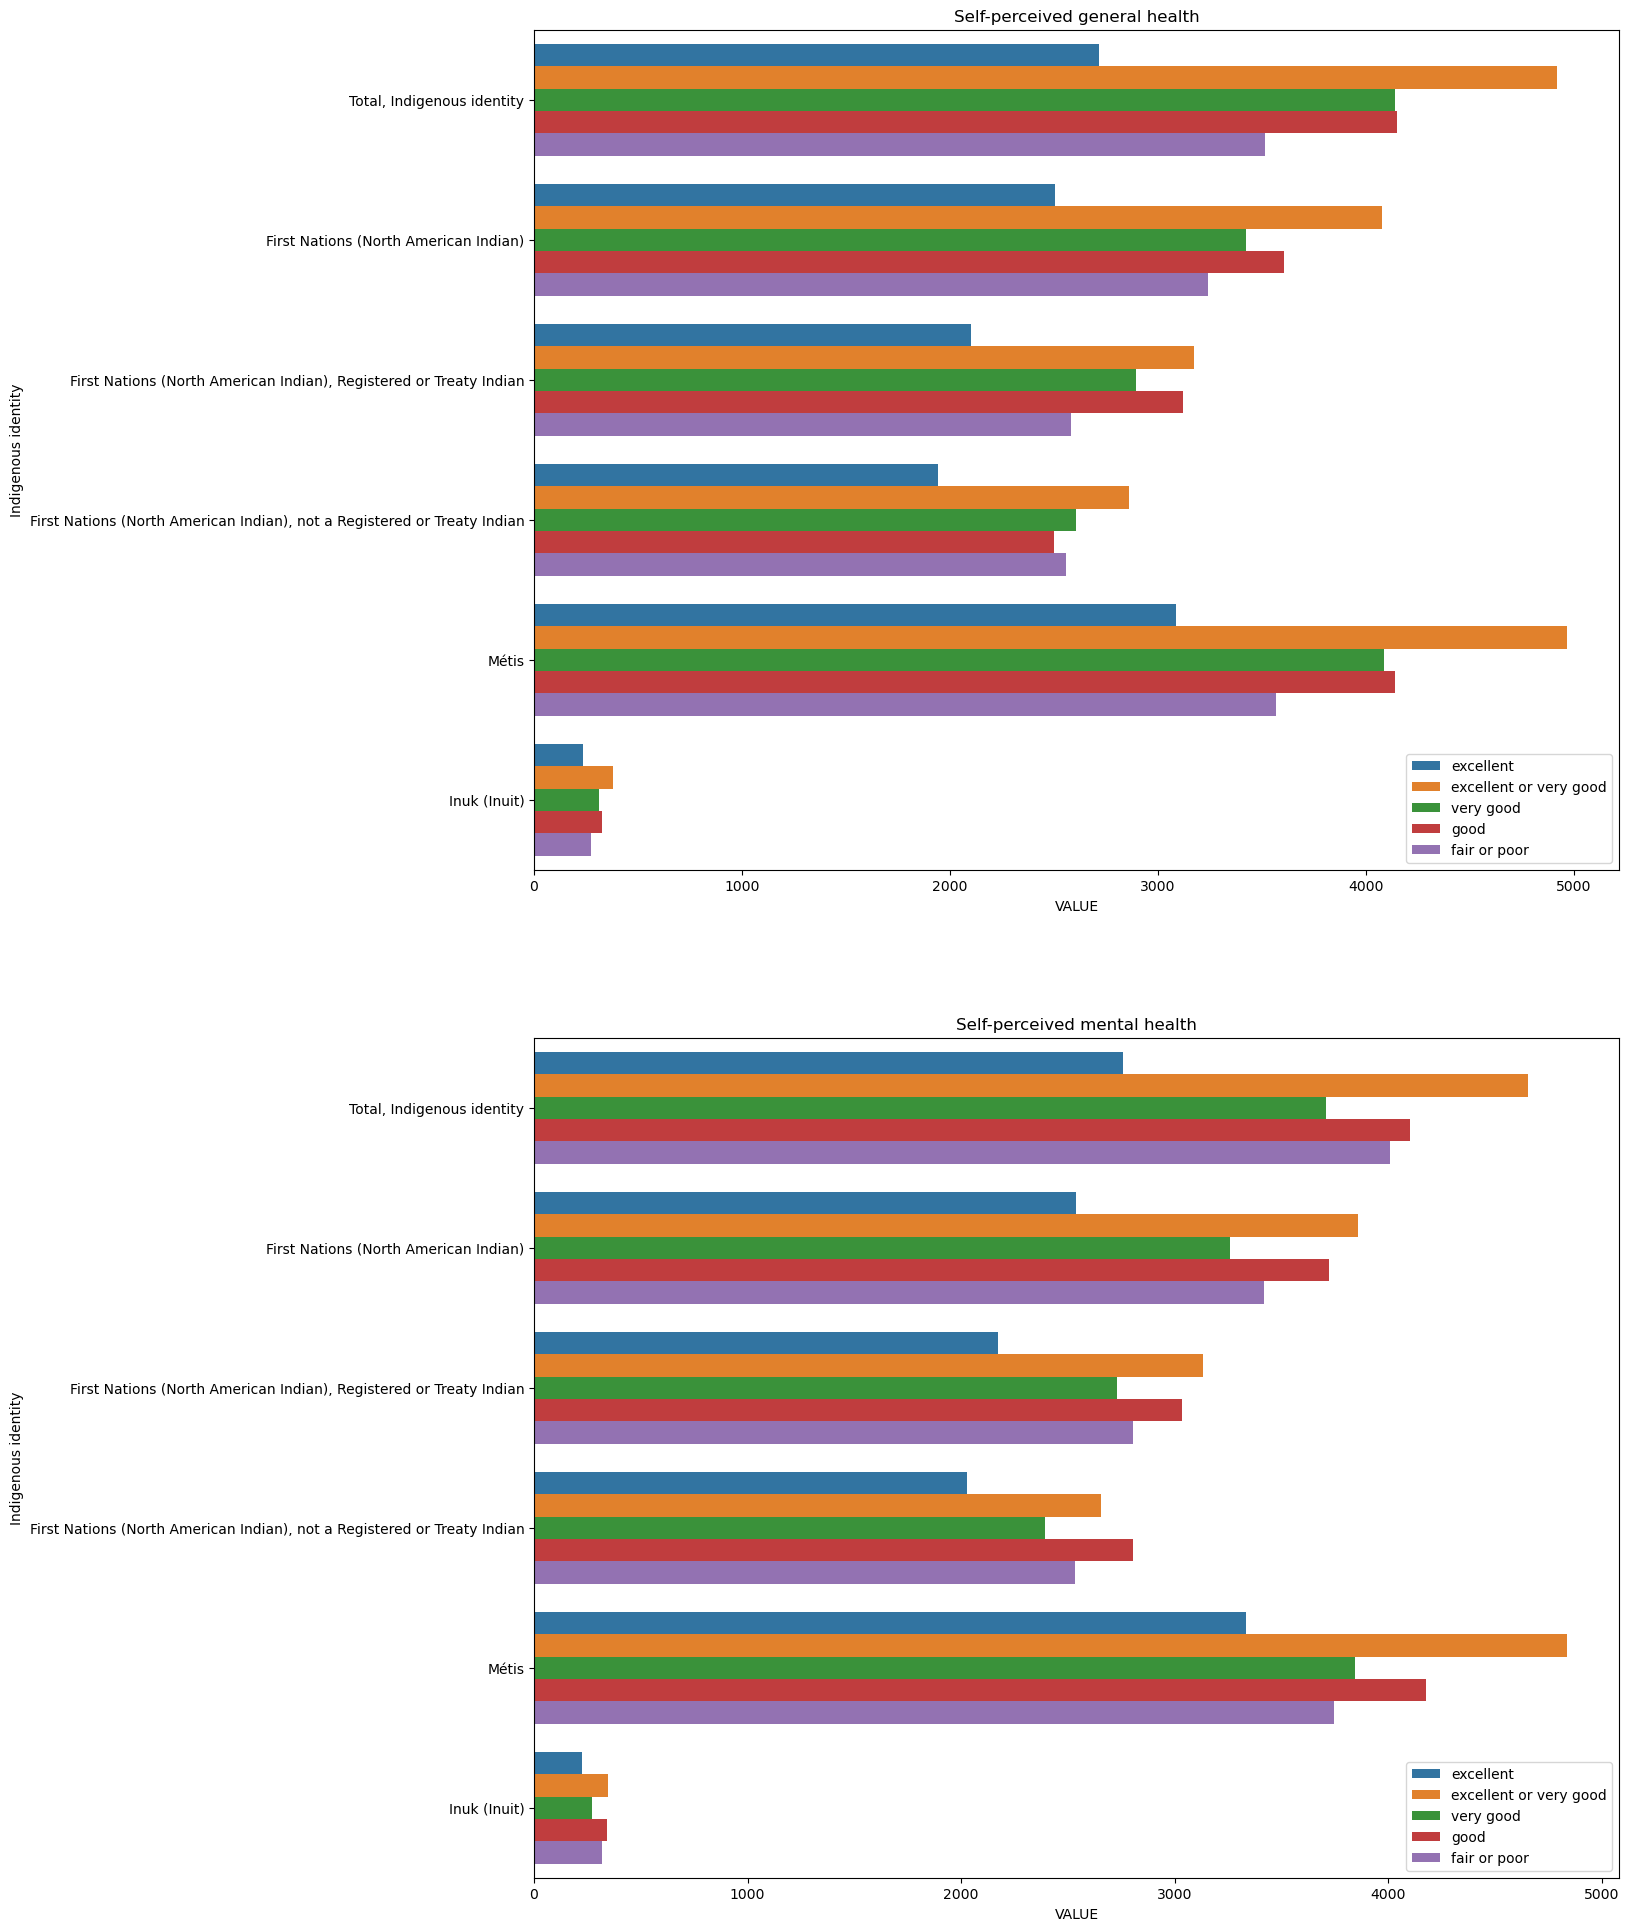

In [117]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(14, 24))

overall_health = dataset[(dataset["Overall health"] != "Total, self-perceived general health") &
                         (dataset["Overall health"] != "Total, self-perceived mental health")]

health_general = overall_health[overall_health["Overall health"].str.match("^Self-perceived general")]
health_mental = pd.concat([overall_health, health_general]).drop_duplicates(keep=False)
health_general["Overall health"] = health_general["Overall health"].str.replace("Self-perceived general health, ", "").str.rstrip()
health_mental["Overall health"] = health_mental["Overall health"].str.replace("Self-perceived mental health, ", "").str.rstrip()

indigenous_identity = overall_health["Indigenous identity"].unique()
health_order = ["excellent", "excellent or very good", "very good", "good", "fair or poor"]
ordered_health_index = pd.MultiIndex.from_product([indigenous_identity, health_order], names=["Indigenous identity", "Overall health"])

id_vs_health_general = health_general.pivot_table(index=["Indigenous identity", "Overall health"], values="VALUE")
id_vs_health_mental = health_mental.pivot_table(index=["Indigenous identity", "Overall health"], values="VALUE")
id_vs_health_general = id_vs_health_general.reindex(ordered_health_index)
id_vs_health_mental = id_vs_health_mental.reindex(ordered_health_index)
# display(id_vs_health_general)


plot_general = sb.barplot(data=id_vs_health_general, y="Indigenous identity", x="VALUE", hue="Overall health", hue_order= health_order, ax=axes[0])
axes[0].set_title("Self-perceived general health")
plot_general.legend_.set_title("")

plot_mental = sb.barplot(data=id_vs_health_mental, y="Indigenous identity", x="VALUE", hue="Overall health", ax=axes[1])
axes[1].set_title("Self-perceived mental health")
plot_mental.legend_.set_title("")

plt.show()

<Axes: xlabel='VALUE', ylabel='Indigenous identity'>

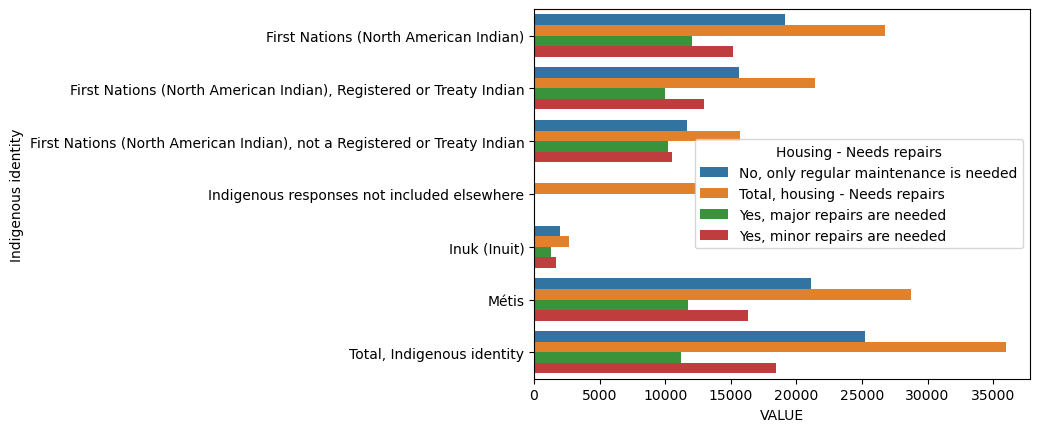

In [116]:
housings = no_of_persons.pivot_table(index=["Indigenous identity", "Housing - Needs repairs"], values="VALUE")

# housing_new_index = {
#     "No, only regular maintenance is needed": "No - Just needs regular maintenance",
#     "Total, housing - Needs repairs": "Total - Needs repairs",
#     "Yes, major repairs are needed": "Yes - Needs major repairs",
#     "Yes, minor repairs are needed": "Yes - Needs minor repairs"
# }
# mapped_index = housings.index.get_level_values("Housing - Needs repairs").map(housing_new_index)
# new_index = housings.index.set_levels(mapped_index, level="Housing - Needs repairs")
# display(mapped_index)

sb.barplot(data=housings, x="VALUE", y="Indigenous identity", hue="Housing - Needs repairs")